In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
import biparallel
import os

In [2]:
basedir = '/home/mzennaro/CosmoCodes/Simulations/N768_L256/nenya_N768_output/0.00/'
if os.path.exists(basedir) == False:
    basedir = '/home/zennaro/CosmoCodes/Simulations/N768_L256/nenya_N768_output/0.00/'
halo_file = 'groups_081/fof_subhalo_history_tab_orph_wweight_081'
sim = bacco.Simulation(basedir=basedir, halo_file=halo_file)
sim

2026-06-10 16:10:34,521 bacco.sims : Initialising simulation Default
2026-06-10 16:10:34,525 bacco.sims : Loading /home/zennaro/CosmoCodes/Simulations/N768_L256/nenya_N768_output/0.00/groups_081/fof_subhalo_history_tab_orph_wweight_081
2026-06-10 16:10:34,536 bacco.cosmo : Initialising 'Default' cosmology at z=0.00


Simulation(tag='Default', cosmo='Default', box=256.0, a=0.9990212338420196, z=0.001, N=452984832, format='gadget_hdf5', seed=-406168)

In [3]:
ngrid = 256
density_mesh = bacco.statistics.compute_mesh(ngrid=ngrid, box=sim.header['BoxSize'], pos=sim.sdm['pos'], vel=None,
                                             interlacing=True, deposit_method='tsc', folds=1, compensated=True,
                                             zspace=False, cosmology=sim.Cosmology, nthreads=None, twod=False)
density_mesh /= np.mean(density_mesh)
density_mesh -= 1

2026-06-10 16:10:34,582 bacco.sims : Reconstructing sDM
2026-06-10 16:10:34,659 bacco.sims : Reading sDM (single pass): pos, offset, len, vel, ids
2026-06-10 16:10:35,139 bacco.sims : Reading 1945855 items for GroupVel
2026-06-10 16:10:35,314 bacco.sims : Reading 1945855 items for GroupPos
2026-06-10 16:10:35,579 bacco.sims : Done reconstructing sDM
2026-06-10 16:10:35,580 bacco.statistics : Computing tsc mesh with 7077888 objects, ngrid=256, interlacing=True, and nthreads=4
bacco.fftw_utils: no FFTW wisdom for ngrid=256 nthreads=4 (out-of-place); building plans with FFTW_MEASURE (can take minutes for large grids; result will be saved to the wisdom file)...
bacco.fftw_utils: FFTW_MEASURE planning for ngrid=256 (out-of-place) done in 10.2 s (wisdom saved)


In [4]:
kmin = 2 * np.pi / sim.header['BoxSize']
kmax = np.pi * ngrid / sim.header['BoxSize'] / 2

dlogk = 0.1
kbins_log = np.arange(np.log10(kmin), np.log10(kmax), dlogk)
kbins_edges = 10**kbins_log

print(kbins_edges)
print(kbins_edges.shape)

[0.02454369 0.03089868 0.03889913 0.0489711  0.06165097 0.07761397
 0.0977102  0.12300985 0.15486023 0.19495748 0.24543693 0.30898678
 0.38899131 0.48971105 0.61650968 0.77613971 0.977102   1.23009854
 1.54860231]
(19,)


In [5]:
bp = biparallel.BiParallel(density_mesh, sim.header['BoxSize'])
bp.print_mesh()

density_mesh ndim=3 shape=(256, 256, 256)


In [6]:
my_bisp = bp.compute_bispectrum(kbins_edges)

density_mesh ndim=3 shape=(256, 256, 256)


/home/zennaro/CosmoCodes/biparallel/biparallel/biparallel.py:67: RuntimeWarning: divide by zero encountered in divide
  bispectrum = raw_bispectrum / normalization * self.Lbox**6 / self.density_mesh.size**3
/home/zennaro/CosmoCodes/biparallel/biparallel/biparallel.py:61: RuntimeWarning: invalid value encountered in divide
  self.effective_triangles = effective_triangles / normalization


In [ ]:
from bisputils import BaccoBispectrum
bb = BaccoBispectrum(sim)
big_res = bb.compute_bispectrum_BiG(ngrid=ngrid, kmin=kmin, kmax=kmax, dk=dlogk, binning_mode='log', compensated=True)

2026-06-10 16:17:10,362 bacco.statistics : Computing tsc mesh with 7077888 objects, ngrid=256, interlacing=True, and nthreads=4


[CpuDevice(id=0)]
N bins: 18
kbins: [0.02454369 0.03089868 0.03889913 0.0489711  0.06165097 0.07761397
 0.0977102  0.12300985 0.15486023 0.19495748 0.24543693 0.30898678
 0.38899131 0.48971105 0.61650968 0.77613971 0.977102   1.23009854
 1.54860231]
Finished setting members of bispectrumExtractor
Creating k-mesh


(318,)
(318,)


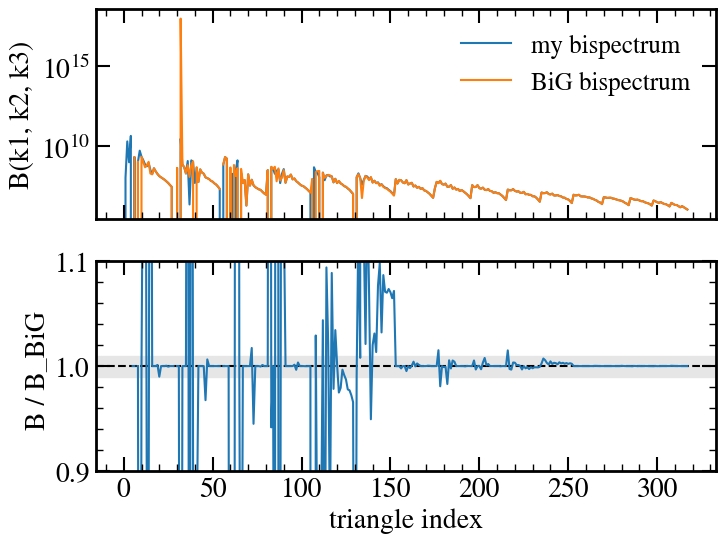

In [ ]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

trindex = np.arange(len(my_bisp['bispectrum']))
ax[0].semilogy(trindex, my_bisp['bispectrum'], label='my bispectrum')
ax[0].semilogy(trindex, big_res['bispectrum'], label='BiG bispectrum')
ax[1].axhspan(0.99, 1.01, color='0.9')
ax[1].axhline(1, color='k', ls='--')
ax[1].plot(trindex, my_bisp['bispectrum'] / big_res['bispectrum'])
ax[1].set_xlabel('triangle index')
ax[0].set_ylabel('B(k1, k2, k3)')
ax[1].set_ylabel('B / B_BiG ')
ax[0].legend()

ax[1].set_ylim(0.9, 1.1)
print(big_res['bispectrum'].shape)
print(my_bisp['bispectrum'].shape)

plt.show()

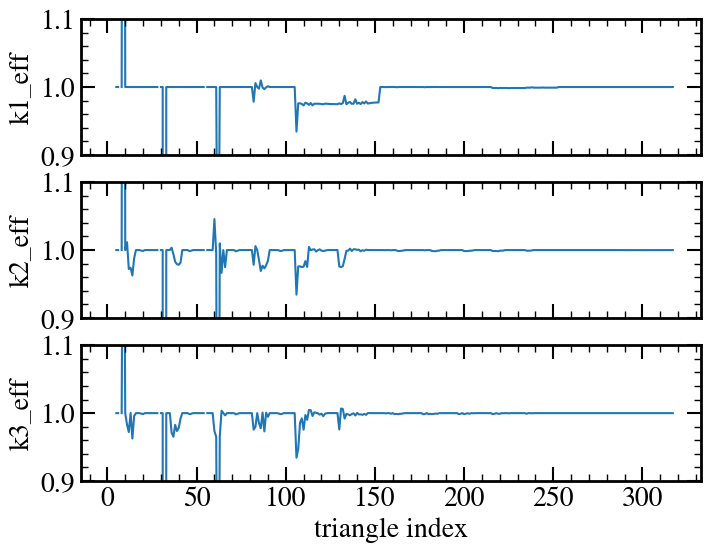

In [ ]:
%matplotlib inline

my_k1_eff, my_k2_eff, my_k3_eff = my_bisp['effective_triangles']
big_k1_eff, big_k2_eff, big_k3_eff = big_res['effective_triangles']

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(8, 6))
ax[0].plot(trindex, my_k1_eff / big_k1_eff, label='my k1_eff')
ax[1].plot(trindex, my_k2_eff / big_k2_eff, label='my k2_eff')
ax[2].plot(trindex, my_k3_eff / big_k3_eff, label='my k3_eff')

ax[0].set_ylabel('k1_eff')
ax[1].set_ylabel('k2_eff')
ax[2].set_ylabel('k3_eff')
ax[2].set_xlabel('triangle index')

ax[0].set_ylim(0.9, 1.1)
ax[1].set_ylim(0.9, 1.1)
ax[2].set_ylim(0.9, 1.1)

plt.show()